In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, f1_score
)

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# LOGISTIC REGRESSION (BASELINE)

In [ ]:
log_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='liblinear'
    ))
])

log_pipeline.fit(X_train, y_train)

y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]

print("\n===== LOGISTIC REGRESSION =====")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


===== LOGISTIC REGRESSION =====
ROC-AUC: 0.9720964198144085


In [ ]:
threshold = 0.9
y_pred_log = (y_prob_log >= threshold).astype(int)

In [ ]:
print("\n===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_log))


===== FINAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.89      0.39        98

    accuracy                           1.00     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix (Logistic):")
print(cm_log)

Confusion Matrix (Logistic):
[[56599   265]
 [   11    87]]



===== CONFUSION MATRIX =====
[[56599   265]
 [   11    87]]


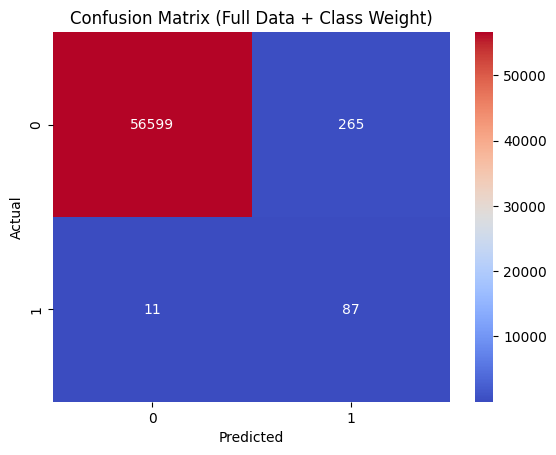

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log)
print("\n===== CONFUSION MATRIX =====")
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (Full Data + Class Weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Here logistic regression achieved high recall but suffered from very low precision, indicating a large number of false positives. This highlights its limitation in handling imbalanced and complex fraud data compared to XGBoost

# XGBOOST MODEL

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# RANDOMIZED SEARCH

In [ ]:
param_dist = {
    'n_estimators': [100, 200],   #no of trees
    'max_depth': [3, 5],          #tree complexity
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=5,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

print("\n===== BEST XGBOOST PARAMS =====")
print(random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

===== BEST XGBOOST PARAMS =====
{'subsample': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# XGBOOST EVALUATION

In [ ]:
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n===== XGBOOST =====")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


===== XGBOOST =====
ROC-AUC: 0.9771172608041528


# ROC CURVE

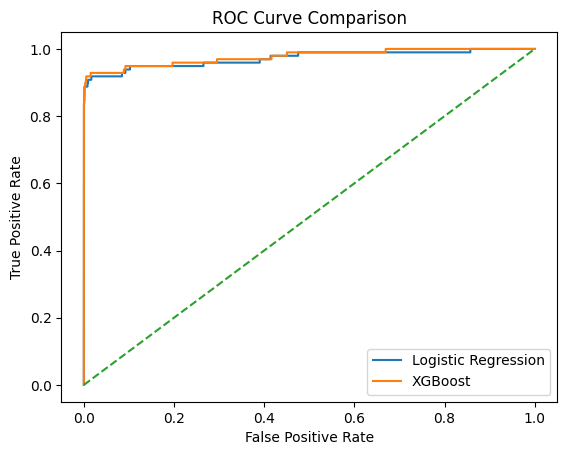

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
y_pred_final = (y_prob_xgb >= 0.4).astype(int)

In [ ]:
print("\n===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_final))


===== FINAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



# CONFUSION MATRIX


===== CONFUSION MATRIX =====
[[56846    18]
 [   16    82]]


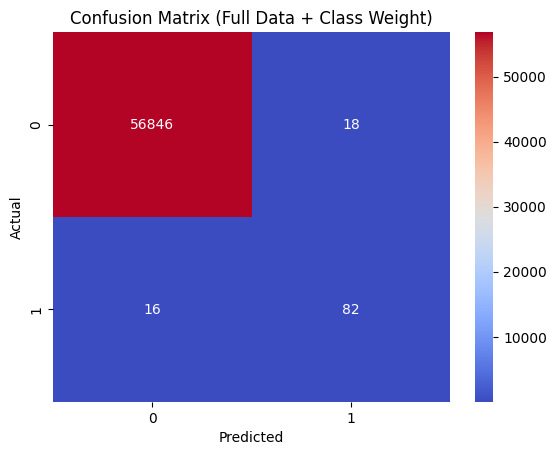

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)
print("\n===== CONFUSION MATRIX =====")
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (Full Data + Class Weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Hyperparameter search
Grid Search → dig everywhere

Random Search → dig randomly (Random Search + Cross Validation (CV))

Bayesian → dig where gold is likely

Grid = brute force (that tries every possible candidate solution until the correct or optimal one is found)

Random = blind search

Bayesian = learning search

param_dist = {
    'max_depth': [3, 5, 7],        # 3 values
    'learning_rate': [0.01, 0.1],  # 2 values
    'n_estimators': [100, 200]     # 2 values
}

3 x 2 x 2 =12 combinations

(3, 0.01, 100)

(3, 0.01, 200)

(3, 0.1, 100)

(3, 0.1, 200)

(5, 0.01, 100)

(5, 0.01, 200)

(5, 0.1, 100)

(5, 0.1, 200)


(7, 0.01, 100)

(7, 0.01, 200)

(7, 0.1, 100)

(7, 0.1, 200)

What GridSearch does-> It tries ALL 12 combinations

What RandomizedSearch does
n_iter = 4
It will pick only 4 random combinations like:

(5, 0.1, 200)

(3, 0.01, 100)

(7, 0.1, 100)

(5, 0.01, 200)

NOT all 12

cv = 3
For EACH combination:
Train model 3 times
On different splits

for eg: (5, 0.1, 200)

Fold 1 → score = 0.94
Fold 2 → score = 0.96
Fold 3 → score = 0.95
Final score = average = 0.95


# Parameters

n_estimators (number of trees)

👉 More trees:

✔ Better learning
❌ More time
❌ Risk of overfitting

👉 Typical range:

[100, 200, 300]
2️⃣ max_depth (tree complexity)

👉 Controls how complex model is

Small → underfitting
Large → overfitting

👉 Typical:

[3, 5, 7]
3️⃣ learning_rate (VERY IMPORTANT 🔥)

👉 How fast model learns

Small → slow but accurate
Large → fast but risky

👉 Typical:

[0.01, 0.05, 0.1]
4️⃣ subsample (row sampling)

👉 Adds randomness → reduces overfitting

[0.7, 0.8, 1]
5️⃣ colsample_bytree (feature sampling)

👉 Use subset of features per tree

[0.7, 0.8, 1]

CV

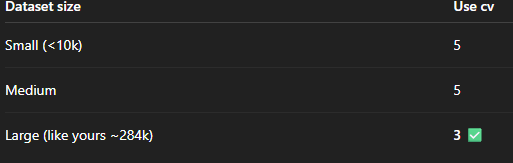

n_iter

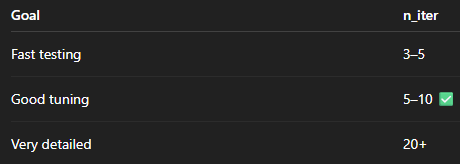

# Bayesian

step 1: Start (like random)

Bayesian begins with a few random trials:

Trial 1 → (lr=0.01, depth=3) → AUC = 0.92  (random)

Trial 2 → (lr=0.1, depth=5) → AUC = 0.96  (random)

Trial 3 → (lr=0.05, depth=7) → AUC = 0.94  

🔹 Step 2: Learn pattern (IMPORTANT 🔥)

Now it understands:

depth=5 → good  
learning_rate=0.1 → very good  

👉 So best region is around:

(learning_rate ≈ 0.1, depth ≈ 5)

🟦 Step 3: Make smart next guess

Instead of random, it chooses:

Trial 4 → (lr=0.08, depth=5)

👉 Why?
Because it is close to best previous result(it will choose no near to .1 only as it came best)

🔹 Step 4: Update knowledge

Suppose:

Trial 4 → AUC = 0.97 (better 🔥)

👉 Now it learns:

“Even better near lr=0.08, depth=5”

🟦 Step 5: Try even smarter
Trial 5 → (lr=0.07, depth=5)
🔁 This keeps repeating
Try → Learn → Improve → Try better
🔥 Final result

👉 After few trials:

Best → (lr=0.08, depth=5)

👉 Found WITHOUT checking all combinations

`Why AUC is Important:`

• Robustness to Class Imbalance: AUC is particularly useful when datasets are highly imbalanced (e.g., 99% legitimate, 1% fraud). Unlike accuracy, which can be misleadingly high if a model just predicts the majority class, AUC focuses on the ranking of predictions, making it a more reliable metric.
Threshold Independence: AUC measures the model's performance across all possible probability thresholds, whereas metrics like precision, recall, and F1-score are tied to a single, chosen threshold.


• Model Comparison: It provides a single scalar value (0 to 1) that allows data scientists to easily compare multiple models. A higher AUC (closer to 1.0) generally indicates better model performance, while 0.5 represents random guessing.


• Probabilistic Interpretation: AUC represents the probability that a model will rank a randomly chosen positive instance higher than a randomly chosen negative instance.


• Separation Ability: It indicates how well the model separates the two distributions of positive and negative classes.
# A higher AUC means less overlap between the predicted scores of the two classes